# Day-Ahead Demand Planning for a Bike-Sharing System

*MLN601 Assessment 3 - Regression, Two Evaluation Protocols and CRISP-DM*

Design and Creative Technologies, Torrens University

- **Student:** Luis Guilherme de Barros Andrade Faria - A00187785
- **Subject Name:** Machine Learning
- **Subject Code:** MLN 601
- **Title:** Day-Ahead Demand Planning for a Bike-Sharing System (Capital Bikeshare)
- **Lecturer:** Dr. Kamran Shaukat
- **Assessment No.:** 3
- **Date:** August 2026

| Field | Value |
|---|---|
| Dataset | UCI Bike Sharing - daily aggregate, Washington DC 2011-2012 (Fanaee-T and Gama, 2014) |
| Target | `cnt`, total daily rentals (continuous) |
| Required algorithm | Regression, expanded into a five-candidate comparison |
| Experiment | Two protocols: random-split interpolation and time-ordered day-ahead forecasting |
| Methodology | CRISP-DM |

Each row in the UCI daily file is one calendar day for the whole system. In this project, I
treat that single row as one operational planning unit, assuming the system is planned centrally
- I am not modelling individual stations or individual bikes. The model's job is to tell an
operator how many rentals to expect tomorrow, so bikes, staff and maintenance windows can be
scheduled the evening before. It is a decision-support tool, where a human always makes the
final call, and no fleet or roster decision is ever taken automatically.

Demand is driven by weather and human behaviour that the dataset records only partly, and the
system grew 64% between the two observed years, so every model is framed as a decision-support
candidate judged against the naive rules an operator could already apply by hand, not as a
replacement for operational judgement.

## 1. Business Understanding

### 1.1 The question, and who asks it

A bike-share operator has to decide how many bikes to have on the street, how many staff to
roster, and when to schedule maintenance. Those decisions are made a day in advance, and they
are made for the system as a whole. The question this project answers is therefore:

> **How many rentals will the system serve tomorrow?**

I use dockless share bikes almost daily in Sydney, for commuting to work and to university and
for errands across the city. That is what makes the variation in this dataset legible to me:
demand collapses in rain, climbs with temperature, and behaves differently on a working day
than on a Sunday. The dataset here is Capital Bikeshare in Washington DC, a **docked** system
observed in 2011 and 2012, so the personal experience motivates the question rather than
supplying evidence for it. The evidence comes from the exploratory analysis in Section 2.

**Scope: system-wide daily demand, not station rebalancing.** The dataset is one row per day
for the whole system. It carries no station identifier, no location, no inventory and no
availability column, so it cannot support a claim about moving bikes between stations. It can
support demand planning, staffing, fleet sizing and maintenance scheduling.

### 1.2 The forecast horizon, stated explicitly

Everything in this report depends on what the model knows when it runs, so I state that first
rather than leaving it implied.

> At prediction time the system knows every daily count up to and including yesterday, plus
> the calendar attributes and the weather forecast for the target day. It does not know the
> target day's realised demand.

This is a **rolling day-ahead** horizon: the model runs at the close of day D to predict day
D+1. Three consequences follow, and each one shapes a design decision later in the notebook.

1. Yesterday's count, last week's count and a trailing seven-day average are **legitimate
   inputs**, not leakage, because that data has genuinely occurred by the time the model runs.
2. The same information is available to any operator for free. A person can read yesterday's
   number off a dashboard. That makes the **naive day-ahead rules the honest adversary** for
   any model I build, not the mean of the training set.
3. The alternative horizon is explicitly rejected. Forecasting all of 2012 on 1 January 2012,
   from 2011 alone, would make every autoregressive input unavailable, force recursive
   prediction with compounding error, and leave the 2011 constant mean as the only valid
   baseline. That comparison would be **easier** to win, not harder. Naming it here is what
   stops the day-ahead choice from reading as a convenient way to pick a weak benchmark.

### 1.3 Two protocols, because the data supports two different claims

The brief asks which model performs best on this dataset. The conventional answer uses a random
train/test split. But a random split over a two-year time series scatters 2012 days into the
training set, so the model is asked to fill gaps *inside* a period it has already seen. That is
interpolation, and it cannot support a claim about forecasting tomorrow.

Rather than pick one and hide the other, this report runs both and keeps their conclusions
separate.

| Protocol | Split | Question it answers | What it is permitted to conclude |
|---|---|---|---|
| **A** | random 75/25 | Which model best explains demand across the observed period? | Names a benchmark winner. Grants no operational approval. |
| **B** | time-ordered, train 2011, confirm 2012 | Can a model forecast tomorrow better than a free naive rule? | Carries the operational decision: approve, approve with conditions, or reject. |

### 1.4 Success criteria, declared before the results

**Protocol A** must beat the mean baseline by at least 40% on MAE, and the error is reported as
a percentage of mean daily demand so it is interpretable without inventing a business tolerance
that no stakeholder in this project has supplied.

**Protocol B** is judged against the strongest naive day-ahead baseline measured on the
identical dates. The model must beat it by a **material 5% margin on MAE** and must not have a
lower R-squared. A model that cannot materially beat a rule an operator could apply by hand is
not a forecaster, however well it scores under Protocol A.

**Tie-break:** models within 5% of each other on MAE are separated by RMSE, which penalises
catastrophic days; if still tied, the simpler and more interpretable model wins.

**Metrics:** MAE is primary, as the brief specifies. MSE, RMSE and R-squared are reported
alongside it because the rubric names them and because they disagree in informative ways.

### 1.5 Decision rules, written before the experiment ran

The conclusion of this report is not pre-written. Protocol B resolves to exactly one of the
following rows, and which row fires is decided by the measured numbers in Section 5.

| Condition | Verdict |
|---|---|
| ML beats the best naive MAE by >= 5% and does not lose on R-squared | Approve with conditions for day-ahead use |
| ML beats the best naive rule, but by less than 5% | No material improvement; the naive rule is retained on simplicity |
| ML MAE is higher than the best naive rule | The naive baseline wins; reject ML for forecasting |
| ML cannot beat even the constant mean | Reject ML forecasting outright |

The second and third rows are different claims and the report does not blur them. A model at
MAE 830 against a naive 847.8 has produced an improvement that is **not material**; it has not
"lost to the naive rule".

### 1.6 Assumptions and limitations, stated here rather than buried

- The dataset records **observed** weather, not the weather *forecast* that would be available
  the evening before. Protocol B therefore assumes a perfect next-day weather forecast and is
  optimistic relative to production.
- Only two years of history exist. Any claim about trend or seasonality rests on a single
  repetition, which is not enough to separate a trend from a level shift.
- Severe weather (`weathersit` category 4) never occurs in the daily file, so no model here has
  any evidence about it. Section 6 turns this into a deployment requirement rather than a
  footnote.
- **2012 is confirmation evidence, not a blind holdout.** It was inspected during the earlier
  version of this project to establish the naive baselines and to test a trend feature, and the
  Protocol B threshold is derived from a baseline measured on it. The criteria were fixed before
  the v3 models were run, which makes the comparison honest, but it is weaker than a
  pre-registered blind test and this report does not claim otherwise.

## 2. Data Understanding

### 2.1 Source and loading

The UCI Bike Sharing dataset (Fanaee-T and Gama, 2014) records daily aggregated rentals for
Capital Bikeshare in Washington DC across 2011 and 2012, alongside calendar attributes and
normalised weather measurements. The daily file `day.csv` is the unit of analysis, matching the
day-ahead question declared in Section 1.

In [1]:
import os
import warnings

# Silence sklearn/joblib parallel UserWarnings so they cannot flood the exported PDF.
# n_jobs=1 in every grid search below means no worker processes spawn either.
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
from pathlib import Path

NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

UCI_URL = ("https://archive.ics.uci.edu/static/public/275/"
           "bike+sharing+dataset.zip")


def load_bike():
    candidates = [BASE_DIR / "dataset" / "day.csv", NB_DIR / "dataset" / "day.csv",
                  NB_DIR / "day.csv"]
    local = next((p for p in candidates if p.exists()), None)
    if local is not None:
        print("Loading local:", local)
        return pd.read_csv(local, parse_dates=["dteday"])
    import io, zipfile, urllib.request
    print("Downloading from UCI:", UCI_URL)
    with urllib.request.urlopen(UCI_URL) as r:
        zf = zipfile.ZipFile(io.BytesIO(r.read()))
    return pd.read_csv(zf.open("day.csv"), parse_dates=["dteday"])


# Chronological order is established here, before any feature is engineered, because every
# lag and rolling feature in Section 3 depends on row order being calendar order.
df = load_bike().sort_values("dteday").reset_index(drop=True)
print("Shape:", df.shape, "| date range:", df.dteday.min().date(), "->", df.dteday.max().date())
df.head()

Loading local: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment3/dataset/day.csv
Shape: (731, 16) | date range: 2011-01-01 -> 2012-12-31


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[us]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[us](1), float64(4), int

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
instant,731.0,366.0,1.0,183.5,366.0,548.5,731.0,211.165812
dteday,731,2012-01-01 00:00:00,2011-01-01 00:00:00,2011-07-02 12:00:00,2012-01-01 00:00:00,2012-07-01 12:00:00,2012-12-31 00:00:00,NaN
season,731.0,2.49658,1.0,2.0,3.0,3.0,4.0,1.110807
yr,731.0,0.500684,0.0,0.0,1.0,1.0,1.0,0.500342
mnth,731.0,6.519836,1.0,4.0,7.0,10.0,12.0,3.451913
holiday,731.0,0.028728,0.0,0.0,0.0,0.0,1.0,0.167155
weekday,731.0,2.997264,0.0,1.0,3.0,5.0,6.0,2.004787
workingday,731.0,0.683995,0.0,0.0,1.0,1.0,1.0,0.465233
weathersit,731.0,1.395349,1.0,1.0,1.0,2.0,3.0,0.544894
temp,731.0,0.495385,0.05913,0.337083,0.498333,0.655417,0.861667,0.183051


In [5]:
# Table 2.1 - data quality audit, run before any modelling decision depends on the answers
span_days = (df["dteday"].max() - df["dteday"].min()).days + 1
gaps = df["dteday"].diff().dropna().dt.days
norm_cols = ["temp", "atemp", "hum", "windspeed"]
in_unit = all(df[c].between(0, 1).all() for c in norm_cols)

audit = pd.DataFrame([
    ("Expected schema and dtypes", "Pass", "Retain"),
    ("Row count matches the daily span",
     f"{len(df)} rows vs {span_days} expected days", "Retain"),
    ("Date continuity (no missing days)",
     "Pass" if gaps.max() == 1 else f"Fail: max gap {int(gaps.max())} days", "Retain"),
    ("Missing values",
     "Pass" if df.isna().sum().sum() == 0 else f"{int(df.isna().sum().sum())} found", "Retain"),
    ("Exact duplicate rows",
     "Pass" if df.duplicated().sum() == 0 else f"{int(df.duplicated().sum())} found", "Retain"),
    ("Identity casual + registered == cnt",
     "Pass" if (df.casual + df.registered == df.cnt).all() else "Fail", "Retain"),
    ("Normalised columns within [0, 1]", "Pass" if in_unit else "Fail", "Retain"),
    ("weathersit categories observed",
     ", ".join(str(k) for k in sorted(df.weathersit.unique())),
     "Category 4 absent: recorded as a domain limit"),
    ("Humidity physically plausible",
     f"Fail: {int((df.hum == 0).sum())} row at hum = 0",
     "Corrected before modelling (Table 2.2)"),
], columns=["check", "result", "action"])

print("Table 2.1 - Data quality audit")
print("Two checks do not pass: severe weather never occurs, and one humidity reading is zero.")
display(audit)

Table 2.1 - Data quality audit
Two checks do not pass: severe weather never occurs, and one humidity reading is zero.


,check,result,action
0,Expected schema and dtypes,Pass,Retain
1,Row count matches the daily span,731 rows vs 731 expected days,Retain
2,Date continuity (no missing days),Pass,Retain
3,Missing values,Pass,Retain
4,Exact duplicate rows,Pass,Retain
5,Identity casual + registered == cnt,Pass,Retain
6,"Normalised columns within [0, 1]",Pass,Retain
7,weathersit categories observed,"1, 2, 3",Category 4 absent: recorded as a domain limit
8,Humidity physically plausible,Fail: 1 row at hum = 0,Corrected before modelling (Table 2.2)


In [6]:
# Table 2.2 - outlier and plausibility review, separating statistical from physical problems
def iqr_flags(series):
    q1, q3 = series.quantile([0.25, 0.75])
    lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    return int(((series < lo) | (series > hi)).sum())

rows = [(c, iqr_flags(df[c]), "statistical outlier",
         "Retain: plausible measurement, not verified as an error")
        for c in ["cnt"] + norm_cols]

zero_hum = df.loc[df["hum"] == 0, ["dteday", "weathersit", "hum", "cnt"]]
rows.append(("hum (zero reading)", len(zero_hum), "physically implausible",
             "Correct to missing, impute per training fold"))

outliers = pd.DataFrame(rows, columns=["variable", "rows_flagged", "verdict", "action"])
print("Table 2.2 - Outlier and plausibility review")
print("The IQR flags are retained; the zero-humidity row is a data error and is corrected.")
display(outliers)

print("\nThe implausible row:")
display(zero_hum)

# Zero relative humidity does not occur in nature, and the hourly file confirms the fault:
# this date carries 22 hourly rows instead of 24, all recording hum = 0. Treating it as
# missing lets a median imputer fitted inside each training fold supply a value, which keeps
# the correction out of the test data.
df.loc[df["hum"] == 0, "hum"] = np.nan
print("\nRows now carrying missing humidity:", int(df["hum"].isna().sum()))

Table 2.2 - Outlier and plausibility review
The IQR flags are retained; the zero-humidity row is a data error and is corrected.


,variable,rows_flagged,verdict,action
0,cnt,0,statistical outlier,"Retain: plausible measurement, not verified as..."
1,temp,0,statistical outlier,"Retain: plausible measurement, not verified as..."
2,atemp,0,statistical outlier,"Retain: plausible measurement, not verified as..."
3,hum,2,statistical outlier,"Retain: plausible measurement, not verified as..."
4,windspeed,13,statistical outlier,"Retain: plausible measurement, not verified as..."
5,hum (zero reading),1,physically implausible,"Correct to missing, impute per training fold"



The implausible row:


,dteday,weathersit,hum,cnt
68,2011-03-10,3,0.0,623



Rows now carrying missing humidity: 1


**Reading Tables 2.1 and 2.2.** The dataset is clean in every structural respect that matters:
731 rows for a 731-day span, no missing days, no duplicates, no missing values, and the
`casual + registered == cnt` identity holds exactly. Two findings are not cosmetic. First,
`weathersit` category 4, severe weather, **never occurs**, so no model trained here has any
evidence about that condition and Section 6 turns it into a deployment guardrail. Second, one
row records zero relative humidity, on a day the dataset simultaneously codes as light rain or
snow. Zero relative humidity does not occur in nature, and the hourly companion file records
only 22 hourly observations for that date instead of 24, all with the same zero. That is a
recording fault, not a rare day, so it is corrected to missing and imputed inside each training
fold rather than deleted or silently kept. The IQR flags on the continuous columns are a
different category: they are plausible weather and demand values that happen to sit in the
tails, and removing them would be discarding real signal.

### 2.2 Variables

| Column | Meaning | Role in this project |
|---|---|---|
| `dteday` | Calendar date | Ordering key; not a model input |
| `season`, `mnth`, `weekday` | Calendar position | Predictors; cyclically encoded under Protocol B |
| `yr` | 2011 = 0, 2012 = 1 | Predictor under Protocol A only; under Protocol B it is constant in training |
| `holiday`, `workingday` | Day type flags | Predictors |
| `weathersit` | 1 clear, 2 mist, 3 light rain or snow, 4 severe | Predictor; category 4 never observed |
| `temp`, `atemp`, `hum`, `windspeed` | Normalised weather measurements | Predictors |
| `casual`, `registered` | Membership split of the total | **Excluded**: they sum to the target |
| `cnt` | Total daily rentals | **Target** |

`casual` and `registered` are excluded from every model. They add up to `cnt` exactly, so
including either would hand the model the answer. They remain in the exploratory analysis
because the composition is genuinely informative about who rides and when.

### 2.3 Exploratory data analysis

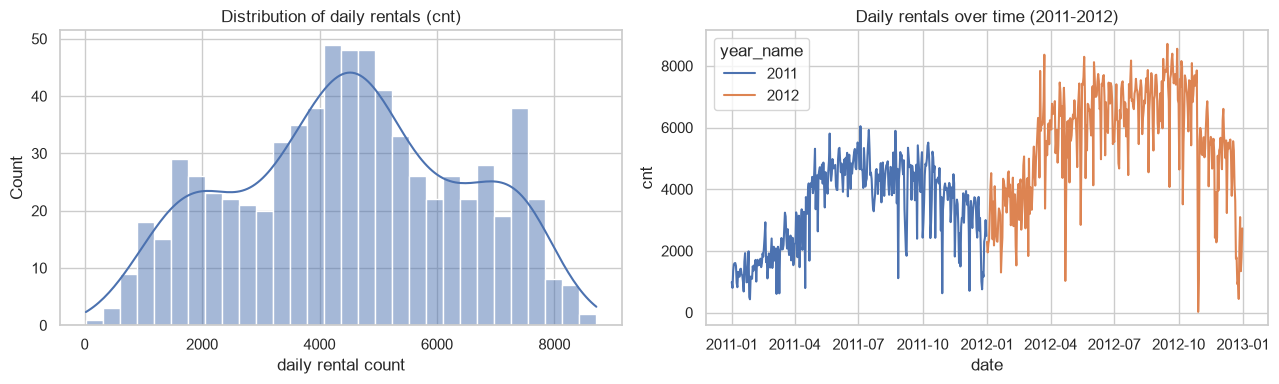

In [7]:
season_lbl = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}
weather_lbl = {1: "clear", 2: "mist", 3: "light rain/snow", 4: "heavy rain/snow"}
weekday_lbl = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
df["season_name"] = df["season"].map(season_lbl)
df["weather_name"] = df["weathersit"].map(weather_lbl)
df["weekday_name"] = df["weekday"].map(weekday_lbl)
df["year_name"] = df["yr"].map({0: "2011", 1: "2012"})

# Distribution of the target and its growth over the two years
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["cnt"], bins=30, kde=True, ax=ax[0])
ax[0].set_title("Distribution of daily rentals (cnt)")
ax[0].set_xlabel("daily rental count")
sns.lineplot(data=df, x="dteday", y="cnt", hue="year_name", ax=ax[1])
ax[1].set_title("Daily rentals over time (2011-2012)")
ax[1].set_xlabel("date"); ax[1].set_ylabel("cnt")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_cnt_distribution.png", dpi=120)
plt.show()

**Read.** The target is right-skewed around a typical ~4,500 rentals a day, and the time series shows a clear upward step from 2011 to 2012 on top of a seasonal wave - so both `yr` and the seasonal calendar will carry signal.

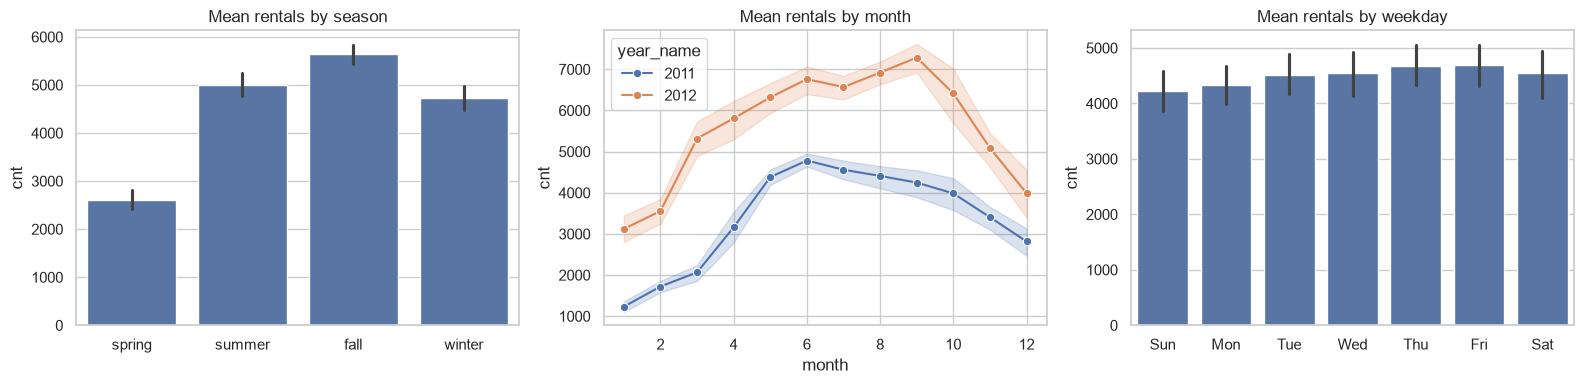

In [8]:
# Season / month / weekday against total rentals (rubric-named plots)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=df, x="season_name", y="cnt",
            order=["spring", "summer", "fall", "winter"], ax=ax[0])
ax[0].set_title("Mean rentals by season"); ax[0].set_xlabel("")
sns.lineplot(data=df, x="mnth", y="cnt", hue="year_name", marker="o", ax=ax[1])
ax[1].set_title("Mean rentals by month"); ax[1].set_xlabel("month")
sns.barplot(data=df, x="weekday_name", y="cnt",
            order=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], ax=ax[2])
ax[2].set_title("Mean rentals by weekday"); ax[2].set_xlabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_season_month_weekday.png", dpi=120)
plt.show()

**Read.** Demand peaks in summer and fall and bottoms in spring/winter; every month sits higher in 2012 than 2011; and weekdays differ little - the weekly cycle is weak for the daily total, unlike the strong seasonal one.

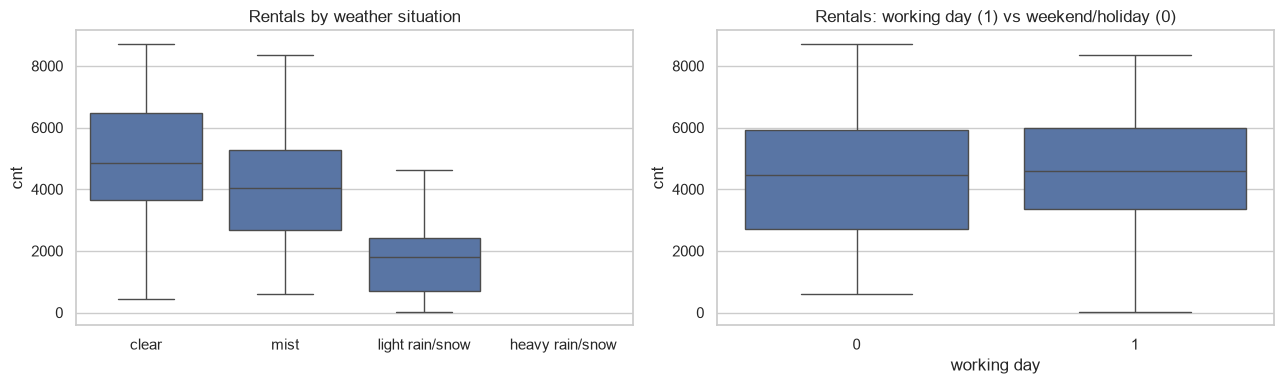

In [9]:
# Weather situation and working-day effect on rentals
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="weather_name", y="cnt",
            order=["clear", "mist", "light rain/snow", "heavy rain/snow"], ax=ax[0])
ax[0].set_title("Rentals by weather situation"); ax[0].set_xlabel("")
sns.boxplot(data=df, x="workingday", y="cnt", ax=ax[1])
ax[1].set_title("Rentals: working day (1) vs weekend/holiday (0)")
ax[1].set_xlabel("working day")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_weather_cnt.png", dpi=120)
plt.show()

**Read.** Clear days carry the most rentals and demand falls step-wise as the weather worsens, with light or heavy rain/snow the lowest. Working days and weekends share a similar median, as commuter and leisure demand offset each other.

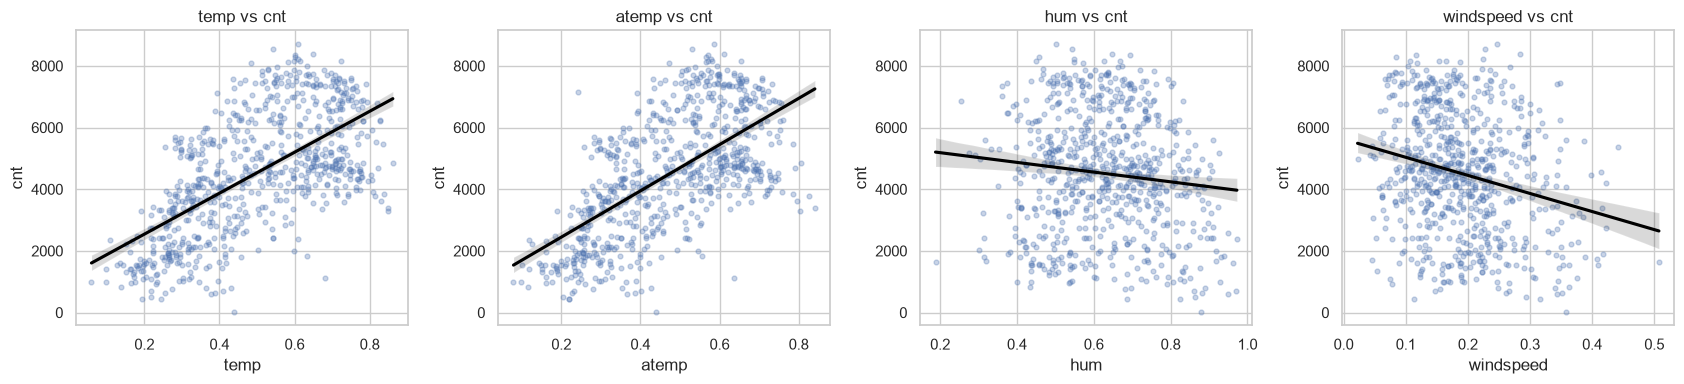

In [10]:
# Continuous weather measures against rentals
cont = ["temp", "atemp", "hum", "windspeed"]
fig, ax = plt.subplots(1, 4, figsize=(17, 4))
for a, c in zip(ax, cont):
    sns.regplot(data=df, x=c, y="cnt", scatter_kws={"alpha": 0.3, "s": 12},
                line_kws={"color": "black"}, ax=a)
    a.set_title(f"{c} vs cnt")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_continuous_vs_cnt.png", dpi=120)
plt.show()

**Read.** Temperature and feels-like temperature (`atemp`) rise strongly with demand - the clearest positive drivers - while humidity and especially wind speed trend mildly negative.

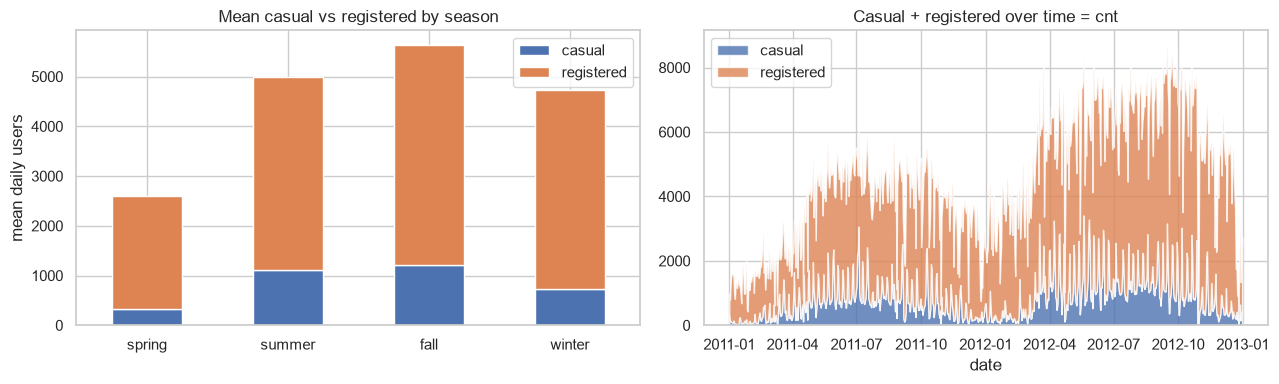

In [11]:
# Casual vs registered composition of total demand
comp = df.groupby("season_name")[["casual", "registered"]].mean().reindex(
    ["spring", "summer", "fall", "winter"])
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
comp.plot(kind="bar", stacked=True, ax=ax[0])
ax[0].set_title("Mean casual vs registered by season")
ax[0].set_xlabel(""); ax[0].set_ylabel("mean daily users")
ax[0].tick_params(axis="x", rotation=0)
ax[1].stackplot(df["dteday"], df["casual"], df["registered"],
                labels=["casual", "registered"], alpha=0.8)
ax[1].set_title("Casual + registered over time = cnt")
ax[1].set_xlabel("date"); ax[1].legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_casual_registered.png", dpi=120)
plt.show()

**Read.** Registered commuters make up the bulk of demand and stay relatively steady year-round, while casual riders swell in the warm seasons - the two segments respond differently to weather, which the single `cnt` target blends together.

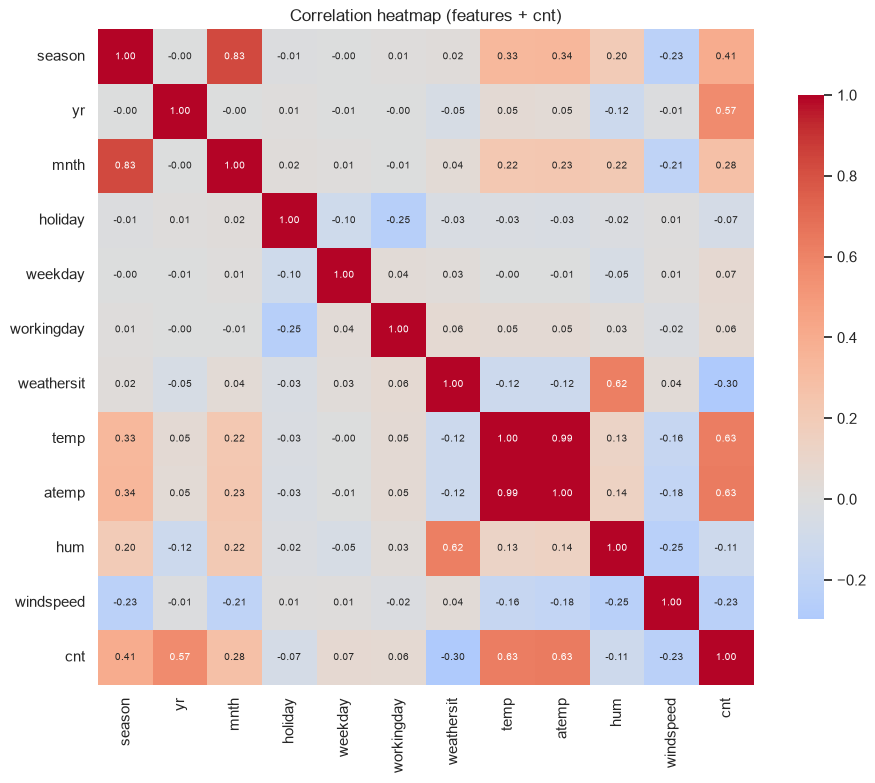

,corr_with_cnt
atemp,0.631
temp,0.627
yr,0.567
season,0.406
mnth,0.280
weekday,0.067
workingday,0.061
holiday,-0.068
hum,-0.115
windspeed,-0.235


In [12]:
# Correlation heatmap of the modelling variables (+ cnt)
num_cols = ["season", "yr", "mnth", "holiday", "weekday", "workingday",
            "weathersit", "temp", "atemp", "hum", "windspeed", "cnt"]
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation heatmap (features + cnt)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_corr_heatmap.png", dpi=120)
plt.show()
corr["cnt"].drop("cnt").sort_values(ascending=False).round(3).to_frame("corr_with_cnt")

**Read.** The heatmap confirms the EDA numerically: `atemp` and `temp` (~0.63) and `yr` (0.57) are the strongest positive correlations with `cnt`, while `weathersit` (-0.30) and `windspeed` (-0.24) are the main negatives. `temp` and `atemp` are near-collinear (~0.99), which destabilises a linear model's coefficients but not the trees.

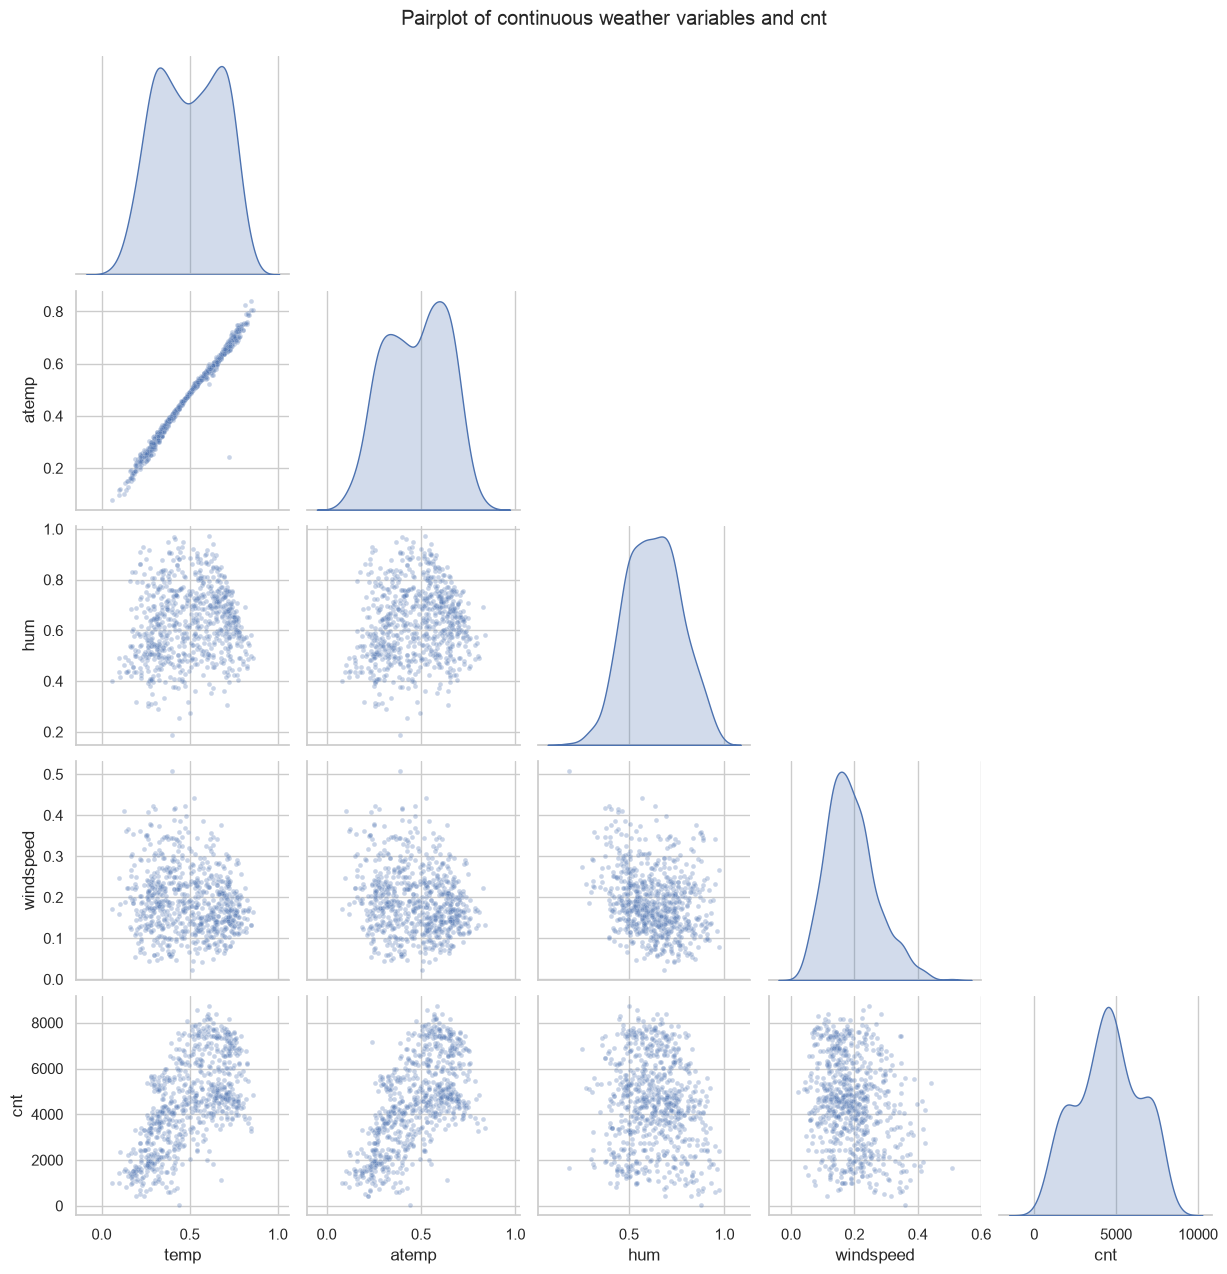

In [13]:
# Seaborn pairplot (required by the brief) - key continuous drivers + target
g = sns.pairplot(df[["temp", "atemp", "hum", "windspeed", "cnt"]],
                 corner=True, plot_kws={"alpha": 0.3, "s": 12}, diag_kind="kde")
g.fig.suptitle("Pairplot of continuous weather variables and cnt", y=1.02)
g.savefig(FIG_DIR / "v3_pairplot.png", dpi=110)
plt.show()

**EDA summary.** Daily demand is driven mostly by **temperature and season**, lifted by the **2011 -> 2012 growth**, and suppressed by **adverse weather, humidity and wind**. The weekly cycle is weak for the daily total because steady registered commuters dominate and offset the more weather-sensitive casual riders. There are no missing values, and the relationships look distinctly non-linear - which should favour the tree ensembles over a straight line.

Table 2.3 - Year-on-year growth, and how much of 2012 sits outside 2011's range
Mean demand grew 64.4%, and almost half of 2012 is above anything 2011 recorded.


,metric,2011,2012
0,mean daily rentals,3406,5600
1,median daily rentals,3740,5927
2,maximum daily rentals,6043,8714
3,days above the 2011 maximum,-,175 of 366 (48%)


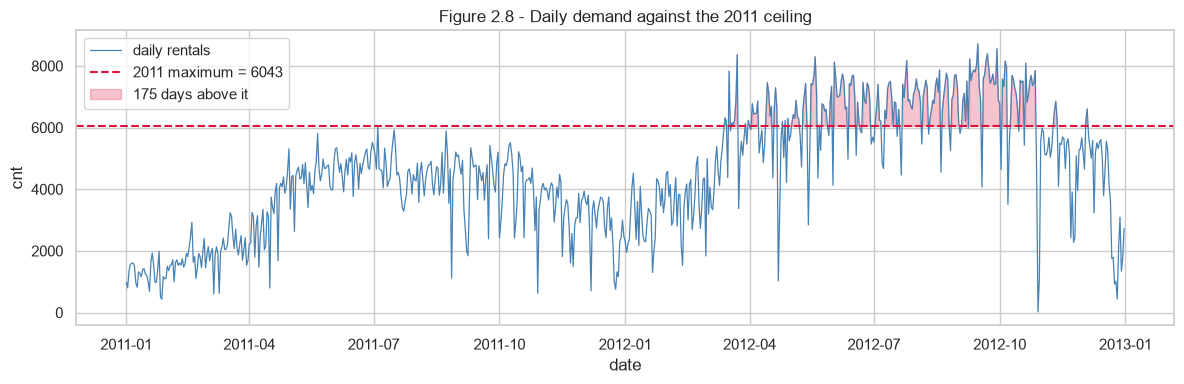

In [14]:
# Figure 2.8 / Table 2.3 - the two-year growth that decides whether forecasting is possible
y11 = df.loc[df["yr"] == 0, "cnt"]
y12 = df.loc[df["yr"] == 1, "cnt"]
ceiling_2011 = int(y11.max())
above = int((y12 > ceiling_2011).sum())

growth = pd.DataFrame({
    "metric": ["mean daily rentals", "median daily rentals", "maximum daily rentals",
               "days above the 2011 maximum"],
    "2011": [round(y11.mean()), round(y11.median()), ceiling_2011, "-"],
    "2012": [round(y12.mean()), round(y12.median()), int(y12.max()),
             f"{above} of {len(y12)} ({above/len(y12)*100:.0f}%)"],
})
print("Table 2.3 - Year-on-year growth, and how much of 2012 sits outside 2011's range")
print(f"Mean demand grew {(y12.mean()/y11.mean()-1)*100:.1f}%, and almost half of 2012 is "
      "above anything 2011 recorded.")
display(growth)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["dteday"], df["cnt"], lw=0.9, color="steelblue", label="daily rentals")
ax.axhline(ceiling_2011, color="crimson", ls="--",
           label=f"2011 maximum = {ceiling_2011}")
ax.fill_between(df["dteday"], ceiling_2011, df["cnt"],
                where=df["cnt"] > ceiling_2011, color="crimson", alpha=0.25,
                label=f"{above} days above it")
ax.set_title("Figure 2.8 - Daily demand against the 2011 ceiling")
ax.set_xlabel("date"); ax.set_ylabel("cnt"); ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_growth_ceiling.png", dpi=120)
plt.show()

**Reading Table 2.3 and Figure 2.8.** Mean daily demand grew 64.4% between the two years, from
about 3,406 to about 5,600 rentals a day. That growth is not a detail, it is the central
difficulty of this project. A tree-based model predicts by averaging training observations, so
it can never output a value above the largest one it was trained on. **175 of the 366 days in
2012, almost half the year, sit above the highest single day in 2011.** Any model trained on
2011 alone is therefore structurally incapable of reaching the right answer on half the days it
is asked about, no matter how well it is tuned. This is the reason Protocol B exists as a
separate experiment, and the reason its adversary is a naive rule rather than another model.

## 3. Data Preparation

Three preparation decisions follow directly from the day-ahead horizon declared in Section 1.

**Chronological order first.** The dataframe was sorted by date at load time, before any
feature was created. Every lag and rolling feature below assumes row order is calendar order,
and a shuffled frame would silently produce features that mix future and past.

**Autoregressive features, built causally.** The day-ahead horizon makes yesterday's demand
available at prediction time, so the model may use it. The construction has to be exact: the
rolling mean is **shifted first and then rolled**, so the window ends on yesterday and never
touches the target day. Assertions below verify this before any number is measured, because a
lag that leaks by one row is invisible in the metrics and fatal to the conclusion.

**Cyclical calendar encoding under Protocol B.** One-hot encoding a month is safe under a
random split, where every month appears in training. It is not safe under a time-ordered split:
the first training fold contains only January to April, so a July validation row encodes to all
zeros, which is exactly what January encodes to. The unseen month becomes indistinguishable
from the reference category. Sine and cosine pairs avoid this entirely by mapping the calendar
onto a circle that is defined for every value, seen or not. `weathersit` stays one-hot because
it is genuinely categorical rather than cyclic, and it is the column the deployment guardrail
in Section 6 protects.

In [15]:
# Autoregressive features. The frame is already in date order, established at load time.
df["lag_1_cnt"] = df["cnt"].shift(1)                        # yesterday
df["lag_7_cnt"] = df["cnt"].shift(7)                        # same weekday last week
df["roll_7_cnt"] = df["cnt"].shift(1).rolling(7).mean()     # shift THEN roll

# Verify causality before anything is measured. A lag that leaks by one row would not show up
# in any metric; it would just make the forecasting result quietly wrong.
for lag, col in [(1, "lag_1_cnt"), (7, "lag_7_cnt")]:
    assert df[col].equals(df["cnt"].shift(lag)), f"{col} is not a pure {lag}-day lag"
probe = 400
assert np.isclose(df.loc[probe, "roll_7_cnt"], df.loc[probe - 7:probe - 1, "cnt"].mean()), \
    "roll_7_cnt includes the target day"
assert df.loc[probe, "roll_7_cnt"] != df.loc[probe - 6:probe, "cnt"].mean(), \
    "roll_7_cnt window is not shifted"
print("Causal lag assertions passed: no autoregressive feature can see the target day.")

# Cyclical calendar encoding (Protocol B), context interactions, and the trend candidate
df["mnth_sin"], df["mnth_cos"] = np.sin(2*np.pi*df.mnth/12), np.cos(2*np.pi*df.mnth/12)
df["weekday_sin"], df["weekday_cos"] = np.sin(2*np.pi*df.weekday/7), np.cos(2*np.pi*df.weekday/7)
df["season_sin"], df["season_cos"] = np.sin(2*np.pi*df.season/4), np.cos(2*np.pi*df.season/4)
df["atemp_hum"] = df["atemp"] * df["hum"]     # muggy days feel worse than either measure implies
df["temp_sq"] = df["temp"] ** 2               # demand falls again at the hot end
df["days_since_start"] = (df["dteday"] - df["dteday"].min()).dt.days

# The seven-day rolling window needs a warm-up, so the first seven days cannot be modelled.
model_df = df.dropna(subset=["roll_7_cnt"]).reset_index(drop=True)
print(f"Modelling rows after the 7-day warm-up: {len(model_df)} "
      f"(from {model_df.dteday.min().date()} to {model_df.dteday.max().date()})")

Causal lag assertions passed: no autoregressive feature can see the target day.
Modelling rows after the 7-day warm-up: 724 (from 2011-01-08 to 2012-12-31)


In [16]:
# Four feature groups, so the ablation in Sections 4 and 5 can attribute any change to a cause
CORE_NOMINAL = ["season", "mnth", "weekday", "weathersit"]   # Protocol A encoding
CORE_BINARY = ["yr", "holiday", "workingday"]
CORE_CONTINUOUS = ["temp", "atemp", "hum", "windspeed"]
CYCLICAL = ["mnth_sin", "mnth_cos", "weekday_sin", "weekday_cos", "season_sin", "season_cos"]
INTERACTIONS = ["atemp_hum", "temp_sq"]
TREND = ["days_since_start"]
AUTOREGRESSIVE = ["lag_1_cnt", "lag_7_cnt", "roll_7_cnt"]

groups_table = pd.DataFrame([
    ("core calendar and weather", len(CORE_NOMINAL + CORE_BINARY + CORE_CONTINUOUS),
     "the conventional feature set both protocols start from"),
    ("context interactions", len(INTERACTIONS),
     "tests whether comfort is more than the sum of its parts"),
    ("trend", len(TREND), "tests whether elapsed time carries the growth signal"),
    ("autoregressive", len(AUTOREGRESSIVE),
     "tests recent demand; only legitimate under the day-ahead horizon"),
], columns=["group", "n_features", "hypothesis it tests"])
print("Table 3.1 - Feature groups and the hypothesis each one tests")
print("Each group is added and removed separately so a metric change can be attributed.")
display(groups_table)


def make_preprocessor(nominal, continuous, binary):
    """Median imputation is fitted inside each training fold, never on the full frame."""
    blocks = []
    if nominal:
        blocks.append(("oh", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal))
    if continuous:
        blocks.append(("sc", Pipeline([("imp", SimpleImputer(strategy="median")),
                                       ("sc", StandardScaler())]), continuous))
    if binary:
        blocks.append(("pass", "passthrough", binary))
    return ColumnTransformer(blocks)


def build_design(protocol, groups):
    """Return the column list and preprocessor for a protocol and set of feature groups."""
    nominal = list(CORE_NOMINAL) if protocol == "A" else ["weathersit"]
    binary = list(CORE_BINARY)
    continuous = list(CORE_CONTINUOUS) + (CYCLICAL if protocol == "B" else [])
    if "inter" in groups:
        continuous += INTERACTIONS
    if "trend" in groups:
        continuous += TREND
    if "auto" in groups:
        continuous += AUTOREGRESSIVE
    return nominal + binary + continuous, make_preprocessor(nominal, continuous, binary)


def reg_metrics(y_true, pred):
    mse = mean_squared_error(y_true, pred)
    return {"MAE": mean_absolute_error(y_true, pred), "MSE": mse,
            "RMSE": float(np.sqrt(mse)), "R2": r2_score(y_true, pred)}

Table 3.1 - Feature groups and the hypothesis each one tests
Each group is added and removed separately so a metric change can be attributed.


,group,n_features,hypothesis it tests
0,core calendar and weather,11,the conventional feature set both protocols st...
1,context interactions,2,tests whether comfort is more than the sum of ...
2,trend,1,tests whether elapsed time carries the growth ...
3,autoregressive,3,tests recent demand; only legitimate under the...


## 4. Modelling

The same five candidates run under both protocols: a mean baseline, Linear Regression,
K-Nearest Neighbors, Random Forest and Gradient Boosting. Keeping the zoo identical is what
makes the two protocols comparable; only the split and the encoding change.

| Candidate | What it tests |
|---|---|
| Mean baseline | The no-skill floor. Any model that cannot beat it has learned nothing. |
| Linear Regression | A global linear response. It is the only candidate here that can **extrapolate** beyond its training range, which turns out to matter enormously under Protocol B. |
| K-Nearest Neighbors | Local similarity. Sensitive to scale, so it sits behind the scaler. |
| Random Forest | Variance reduction by averaging many decorrelated trees. |
| Gradient Boosting | Sequential error correction, usually the strongest tabular learner. |

Hyperparameters are tuned by grid search on MAE, the brief's primary metric. The critical
difference between protocols is **where the tuning happens**: Protocol A tunes with ordinary
5-fold cross-validation, while Protocol B tunes with `TimeSeriesSplit` inside 2011 only, so no
hyperparameter is ever selected using a 2012 observation.

### 4.1 Protocol A - interpolation benchmark on a random 75/25 split

In [17]:
GRIDS = {
    "Linear Regression": (LinearRegression(), {}),
    "K-Nearest Neighbors": (KNeighborsRegressor(), {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__weights": ["uniform", "distance"]}),
    "Random Forest": (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1), {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 8, 16],
        "model__min_samples_leaf": [1, 2, 4]}),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=RANDOM_STATE), {
        "model__n_estimators": [200, 400],
        "model__max_depth": [2, 3],
        "model__learning_rate": [0.05, 0.1]}),
}


def run_zoo(X_tr, y_tr, X_te, y_te, prep, cv):
    """Fit the whole candidate zoo and return metrics, fitted pipelines and chosen params."""
    results, fitted, chosen = {}, {}, {}
    base = Pipeline([("prep", prep), ("model", DummyRegressor(strategy="mean"))])
    base.fit(X_tr, y_tr)
    results["Mean baseline"] = reg_metrics(y_te, base.predict(X_te))
    fitted["Mean baseline"] = base
    for name, (est, grid) in GRIDS.items():
        pipe = Pipeline([("prep", prep), ("model", est)])
        if grid:
            gs = GridSearchCV(pipe, grid, scoring="neg_mean_absolute_error", cv=cv, n_jobs=1)
            gs.fit(X_tr, y_tr)
            fitted[name], chosen[name] = gs.best_estimator_, gs.best_params_
        else:
            fitted[name], chosen[name] = pipe.fit(X_tr, y_tr), {}
        results[name] = reg_metrics(y_te, fitted[name].predict(X_te))
    return results, fitted, chosen


cols_a, prep_a = build_design("A", {"inter"})
Xa, ya = model_df[cols_a], model_df["cnt"]
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
    Xa, ya, test_size=0.25, random_state=RANDOM_STATE)
print(f"Protocol A - train {Xa_tr.shape[0]} rows | test {Xa_te.shape[0]} rows "
      f"| {Xa_tr.shape[1]} input columns")

res_a, fit_a, par_a = run_zoo(Xa_tr, ya_tr, Xa_te, ya_te, prep_a, 5)
table_a = pd.DataFrame(res_a).T.sort_values("MAE").round(3)
table_a.index.name = "model"
table_a.to_csv(OUTPUT_DIR / "protocol_a_metrics_v3.csv")

print("\nTable 4.1 - Protocol A held-out performance (random 75/25)")
print("Gradient Boosting leads, and every real model beats the mean baseline comfortably.")
display(table_a)

Protocol A - train 543 rows | test 181 rows | 13 input columns



Table 4.1 - Protocol A held-out performance (random 75/25)
Gradient Boosting leads, and every real model beats the mean baseline comfortably.


,MAE,MSE,RMSE,R2
model,,,,
Gradient Boosting,458.589,406850.414,637.848,0.868
Random Forest,485.419,480361.483,693.081,0.845
Linear Regression,506.518,448052.612,669.367,0.855
K-Nearest Neighbors,661.742,808631.871,899.240,0.738
Mean baseline,1477.341,3212527.792,1792.353,-0.039


In [18]:
# Table 4.2 - Protocol A feature ablation on the leading family
best_a_name = table_a.drop(index="Mean baseline")["MAE"].idxmin()
est_a, grid_a = GRIDS[best_a_name]
print(f"Leading family under Protocol A: {best_a_name}")

abl_a = []
for label, groups in [("core only", set()), ("core + interactions", {"inter"}),
                      ("core + interactions + trend", {"inter", "trend"}),
                      ("core + interactions + autoregressive", {"inter", "auto"})]:
    cols, prep = build_design("A", groups)
    Xg = model_df[cols]
    Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(
        Xg, model_df["cnt"], test_size=0.25, random_state=RANDOM_STATE)
    gs = GridSearchCV(Pipeline([("prep", prep), ("model", est_a)]), grid_a,
                      scoring="neg_mean_absolute_error", cv=5, n_jobs=1)
    gs.fit(Xg_tr, yg_tr)
    m = reg_metrics(yg_te, gs.best_estimator_.predict(Xg_te))
    abl_a.append({"feature set": label, "MAE": round(m["MAE"], 1),
                  "RMSE": round(m["RMSE"], 1), "R2": round(m["R2"], 3)})
    if label == "core + interactions + trend":
        best_a_model, best_a_cols = gs.best_estimator_, cols
        best_a_test = (Xg_te, yg_te)
        best_a_params = gs.best_params_

abl_a = pd.DataFrame(abl_a)
abl_a.to_csv(OUTPUT_DIR / "protocol_a_ablation_v3.csv", index=False)
print("\nTable 4.2 - Protocol A feature ablation (" + best_a_name + ")")
print("Elapsed time helps here and autoregressive features do not; Section 5 shows the "
      "opposite holds for forecasting.")
display(abl_a)

Leading family under Protocol A: Gradient Boosting



Table 4.2 - Protocol A feature ablation (Gradient Boosting)
Elapsed time helps here and autoregressive features do not; Section 5 shows the opposite holds for forecasting.


,feature set,MAE,RMSE,R2
0,core only,468.5,640.3,0.867
1,core + interactions,458.6,637.8,0.868
2,core + interactions + trend,383.8,548.4,0.903
3,core + interactions + autoregressive,494.4,700.5,0.841


**Reading Tables 4.1 and 4.2.** Gradient Boosting is the Protocol A benchmark winner, reaching
MAE 458.6 with `learning_rate` 0.05, `max_depth` 3 and 400 estimators, against 485.4 for Random
Forest and 506.5 for Linear Regression. That is a 69% improvement on the mean baseline's 1,477,
well past the 40% threshold declared in Section 1, and it corresponds to roughly 10% of mean
daily demand. K-Nearest Neighbors trails at 661.7, which is the expected cost of local
similarity in a space with this many one-hot dimensions.

The ablation is the more interesting table. Adding the two context interactions moves MAE from
468.5 to 458.6, a small but real gain. Adding **elapsed time takes it to 383.8**, the best
result in the whole notebook. That makes sense for interpolation: with 2012 days scattered
through the training set, a counter of days since the start lets the model read the growth
curve directly at any point inside the observed window. Adding autoregressive features instead
makes the benchmark **worse**, at 494.4, which settles a fairness question rather than a
performance one: recent demand is not what a random split is short of, so the Protocol A
headline excludes it and the comparison against the naive rules stays confined to Protocol B
where it belongs.

Hold on to the trend result. Under Protocol B the same feature does the opposite.

### 4.2 Protocol B - day-ahead forecasting, selected in 2011 and confirmed on 2012

Protocol B is the experiment that carries the operational decision, so its discipline is
stricter. Hyperparameters are chosen with `TimeSeriesSplit` **inside 2011 only**, so no 2012
observation influences any modelling choice. The folds are printed below rather than assumed,
because expanding-window folds have a property worth seeing: the first fold trains on winter
and early spring alone and is then validated on late spring and early summer, so the model is
routinely asked about seasons it has never observed. That is not a flaw in the design, it is
the honest shape of forecasting from a short history, and it is the reason the calendar is
encoded cyclically rather than one-hot.

The naive baselines are computed on the identical dates. They are not strawmen: each one is a
rule an operator could apply from a dashboard with no model at all, which is exactly what makes
them the right adversary for a day-ahead forecaster.

In [19]:
train_2011 = model_df[model_df["yr"] == 0].reset_index(drop=True)
test_2012 = model_df[model_df["yr"] == 1].reset_index(drop=True)
cols_b, prep_b = build_design("B", {"inter", "auto"})
Xb_tr, yb_tr = train_2011[cols_b], train_2011["cnt"]
Xb_te, yb_te = test_2012[cols_b], test_2012["cnt"]
print(f"Protocol B - 2011 modelling rows {len(train_2011)} "
      f"| 2012 confirmation rows {len(test_2012)}")

tscv = TimeSeriesSplit(n_splits=3)
fold_rows = []
for k, (tr, va) in enumerate(tscv.split(Xb_tr), 1):
    seen = set(train_2011.loc[tr, "season"])
    unseen = sorted(set(train_2011.loc[va, "season"]) - seen)
    fold_rows.append({
        "fold": k, "train_rows": len(tr), "val_rows": len(va),
        "train_window": f"{train_2011.dteday[tr[0]].date()} to {train_2011.dteday[tr[-1]].date()}",
        "val_window": f"{train_2011.dteday[va[0]].date()} to {train_2011.dteday[va[-1]].date()}",
        "seasons_unseen_in_train": unseen or "none",
    })
print("\nTable 4.3 - TimeSeriesSplit folds inside 2011")
print("Every fold validates on at least one season the training window never contained.")
display(pd.DataFrame(fold_rows))

Protocol B - 2011 modelling rows 358 | 2012 confirmation rows 366

Table 4.3 - TimeSeriesSplit folds inside 2011
Every fold validates on at least one season the training window never contained.


,fold,train_rows,val_rows,train_window,val_window,seasons_unseen_in_train
0,1,91,89,2011-01-08 to 2011-04-08,2011-04-09 to 2011-07-06,[3]
1,2,180,89,2011-01-08 to 2011-07-06,2011-07-07 to 2011-10-03,[4]
2,3,269,89,2011-01-08 to 2011-10-03,2011-10-04 to 2011-12-31,none


In [20]:
# Table 4.4 - naive day-ahead baselines, evaluated on exactly the 2012 dates the models see
naive_preds = {
    "Naive lag-1": test_2012["lag_1_cnt"].to_numpy(),
    "Naive lag-7": test_2012["lag_7_cnt"].to_numpy(),
    "Naive rolling-7": test_2012["roll_7_cnt"].to_numpy(),
    "2011 constant mean": np.full(len(test_2012), train_2011["cnt"].mean()),
}
res_b = {name: reg_metrics(yb_te, p) for name, p in naive_preds.items()}

naive_table = pd.DataFrame(res_b).T.sort_values("MAE").round(3)
naive_table.index.name = "baseline"
print("Table 4.4 - Naive day-ahead baselines on 2012")
print("The trailing seven-day mean is the one to beat, not the constant mean.")
display(naive_table)

Table 4.4 - Naive day-ahead baselines on 2012
The trailing seven-day mean is the one to beat, not the constant mean.


,MAE,MSE,RMSE,R2
baseline,,,,
Naive rolling-7,847.849,1388485.776,1178.340,0.565
Naive lag-1,870.175,1553433.787,1246.368,0.513
Naive lag-7,1110.396,2439375.057,1561.850,0.235
2011 constant mean,2460.197,7829760.182,2798.171,-1.454


In [21]:
# Fit the same zoo under Protocol B. Tuning uses TimeSeriesSplit inside 2011 only, so no
# hyperparameter is ever chosen with a 2012 observation in view.
ml_res_b, fit_b, par_b = run_zoo(Xb_tr, yb_tr, Xb_te, yb_te, prep_b, tscv)
pred_b = {name: m.predict(Xb_te) for name, m in fit_b.items()}
res_b.update(ml_res_b)

table_b = pd.DataFrame(res_b).T.sort_values("MAE").round(3)
table_b.index.name = "model"
table_b.to_csv(OUTPUT_DIR / "protocol_b_metrics_v3.csv")

print("Table 4.5 - Protocol B, 2012 confirmation performance")
print("Read the ordering before the numbers: two naive rules occupy the top of the table.")
display(table_b)

for name in GRIDS:
    print(f"  {name:22s} selected {par_b[name]}")

Table 4.5 - Protocol B, 2012 confirmation performance
Read the ordering before the numbers: two naive rules occupy the top of the table.


,MAE,MSE,RMSE,R2
model,,,,
Naive rolling-7,847.849,1388485.776,1178.340,0.565
Naive lag-1,870.175,1553433.787,1246.368,0.513
Linear Regression,1047.442,1449638.986,1204.010,0.546
Naive lag-7,1110.396,2439375.057,1561.850,0.235
Gradient Boosting,1627.892,3268204.685,1807.818,-0.024
Random Forest,1675.708,3474636.958,1864.038,-0.089
K-Nearest Neighbors,1738.997,3810063.843,1951.938,-0.194
2011 constant mean,2460.197,7829760.182,2798.171,-1.454
Mean baseline,2460.197,7829760.182,2798.171,-1.454


  Linear Regression      selected {}
  K-Nearest Neighbors    selected {'model__n_neighbors': 9, 'model__weights': 'distance'}
  Random Forest          selected {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
  Gradient Boosting      selected {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}


In [22]:
# Table 4.6 - Protocol B feature ablation on the leading ML family
ml_only_b = {k: v for k, v in res_b.items() if k in GRIDS}
best_b_name = min(ml_only_b, key=lambda k: ml_only_b[k]["MAE"])
est_b, grid_b = GRIDS[best_b_name]
print(f"Leading ML family under Protocol B: {best_b_name}")

abl_b = []
for label, groups in [("core only", set()), ("core + interactions", {"inter"}),
                      ("core + interactions + autoregressive", {"inter", "auto"}),
                      ("core + interactions + autoregressive + trend", {"inter", "auto", "trend"})]:
    cols, prep = build_design("B", groups)
    pipe = Pipeline([("prep", prep), ("model", est_b)])
    if grid_b:
        gs = GridSearchCV(pipe, grid_b, scoring="neg_mean_absolute_error", cv=tscv, n_jobs=1)
        gs.fit(train_2011[cols], yb_tr)
        fitted_g = gs.best_estimator_
    else:
        fitted_g = pipe.fit(train_2011[cols], yb_tr)
    m = reg_metrics(yb_te, fitted_g.predict(test_2012[cols]))
    abl_b.append({"feature set": label, "MAE": round(m["MAE"], 1),
                  "RMSE": round(m["RMSE"], 1), "R2": round(m["R2"], 3)})

abl_b = pd.DataFrame(abl_b)
abl_b.to_csv(OUTPUT_DIR / "protocol_b_ablation_v3.csv", index=False)
print("\nTable 4.6 - Protocol B feature ablation (" + best_b_name + ")")
print("Autoregressive features are what make forecasting viable at all; elapsed time now hurts.")
display(abl_b)

Leading ML family under Protocol B: Linear Regression

Table 4.6 - Protocol B feature ablation (Linear Regression)
Autoregressive features are what make forecasting viable at all; elapsed time now hurts.


,feature set,MAE,RMSE,R2
0,core only,2145.3,2366.8,-0.756
1,core + interactions,2044.3,2214.5,-0.537
2,core + interactions + autoregressive,1047.4,1204.0,0.546
3,core + interactions + autoregressive + trend,1124.4,1279.3,0.487


**Reading Tables 4.3 to 4.6.** The fold table shows what a short history costs: fold 1 trains on
91 days of winter and early spring and is validated on 89 days of late spring and summer, and
every fold validates on at least one season its training window never contained. Cyclical
encoding is what keeps those unseen months from collapsing onto the reference category.

Table 4.5 is the result this project exists to report. **Two naive rules occupy the top of the
table.** The trailing seven-day mean forecasts 2012 at MAE 847.8 with R-squared 0.565, and
yesterday's count alone reaches 870.2. The best machine-learning model, Linear Regression at
1,047.4, is 23.5% *worse* than a rule that requires no model, no training and no maintenance.
The two tree ensembles are not merely beaten, they are catastrophic: Gradient Boosting reaches
MAE 1,627.9 and Random Forest 1,675.7, both with **negative R-squared**, meaning they predict
2012 worse than simply guessing the 2012 average would have. Section 5 shows exactly why.

The ablation explains what little success there is. Under Protocol B the core calendar and
weather features alone give MAE 2,145.3, worse than the constant mean. Adding the
autoregressive group cuts that to 1,047.4, so essentially all of the forecasting signal
available to these models comes from recent demand rather than from the calendar or the
weather. And elapsed time, the feature that produced the best result in the entire notebook
under Protocol A, now makes things **worse**, moving MAE from 1,047.4 to 1,124.4. The same
column helps when the model interpolates inside the period it has seen and hurts when it has to
step past it, because all a trend counter can do outside the training range is extend a slope
that was only ever fitted inside it.

## 5. Evaluation

### 5.1 Applying the gates declared in Section 1

In [23]:
# Table 5.1 - each protocol judged against the criteria fixed before the experiment ran
mean_demand = model_df["cnt"].mean()
# The gate is applied to the configuration the ablation actually selected, not to the
# intermediate one used for the model-versus-model comparison in Table 4.1.
a_win = best_a_name
a_mae = float(reg_metrics(best_a_test[1], best_a_model.predict(best_a_test[0]))["MAE"])
a_baseline_mae = float(table_a.loc["Mean baseline", "MAE"])
a_gain = 1 - a_mae / a_baseline_mae

best_naive = naive_table.index[0]
naive_mae = float(naive_table.loc[best_naive, "MAE"])
naive_r2 = float(naive_table.loc[best_naive, "R2"])
gate_mae, gate_r2 = naive_mae * 0.95, naive_r2

b_win = min({k: v for k, v in res_b.items() if k in GRIDS},
            key=lambda k: res_b[k]["MAE"])
b_mae, b_r2 = res_b[b_win]["MAE"], res_b[b_win]["R2"]

gates = pd.DataFrame([
    ("A", "beat the mean baseline by >= 40% on MAE",
     f"MAE {a_mae:.1f} vs {a_baseline_mae:.1f}: {a_gain*100:.1f}% improvement",
     "Pass" if a_gain >= 0.40 else "Fail"),
    ("A", "report MAE against mean daily demand",
     f"MAE {a_mae:.1f} = {a_mae/mean_demand*100:.1f}% of {mean_demand:.0f}", "Reported"),
    ("B", f"MAE <= {gate_mae:.1f} (5% better than {best_naive})",
     f"{b_win}: MAE {b_mae:.1f}", "Pass" if b_mae <= gate_mae else "Fail"),
    ("B", f"R-squared > {gate_r2:.3f} ({best_naive})",
     f"{b_win}: R2 {b_r2:.3f}", "Pass" if b_r2 > gate_r2 else "Fail"),
], columns=["protocol", "declared criterion", "measured", "verdict"])
gates.to_csv(OUTPUT_DIR / "gate_application_v3.csv", index=False)

print("Table 5.1 - Gate application, criteria fixed in Section 1 before any v3 model ran")
print(f"Protocol A clears its bar. Protocol B fails both of its gates.")
display(gates)

Table 5.1 - Gate application, criteria fixed in Section 1 before any v3 model ran
Protocol A clears its bar. Protocol B fails both of its gates.


,protocol,declared criterion,measured,verdict
0,A,beat the mean baseline by >= 40% on MAE,MAE 383.8 vs 1477.3: 74.0% improvement,Pass
1,A,report MAE against mean daily demand,MAE 383.8 = 8.5% of 4535,Reported
2,B,MAE <= 805.5 (5% better than Naive rolling-7),Linear Regression: MAE 1047.4,Fail
3,B,R-squared > 0.565 (Naive rolling-7),Linear Regression: R2 0.546,Fail


In [24]:
# The decision rule that fires is determined by the measured numbers, not chosen afterwards
margin = (naive_mae - b_mae) / naive_mae
const_mae = float(naive_table.loc["2011 constant mean", "MAE"])

if b_mae > const_mae:
    verdict = "Reject ML forecasting outright: it cannot beat even the constant mean."
elif b_mae > naive_mae:
    verdict = (f"The naive baseline wins. {best_naive} forecasts 2012 at MAE {naive_mae:.1f}; "
               f"the best model, {b_win}, reaches only {b_mae:.1f}, which is "
               f"{abs(margin)*100:.1f}% worse. Reject ML for day-ahead forecasting.")
elif margin < 0.05:
    verdict = (f"{b_win} beats {best_naive} by {margin*100:.1f}%, below the 5% materiality "
               "threshold. The improvement is not material and the naive rule is retained "
               "on simplicity. This is not the same as the naive rule winning.")
else:
    verdict = (f"Approve {b_win} with conditions for day-ahead use: MAE {b_mae:.1f} against "
               f"{naive_mae:.1f}, a {margin*100:.1f}% material improvement.")

print("Decision rule fired (Section 1.5):")
print(" ", verdict)

Decision rule fired (Section 1.5):
  The naive baseline wins. Naive rolling-7 forecasts 2012 at MAE 847.8; the best model, Linear Regression, reaches only 1047.4, which is 23.5% worse. Reject ML for day-ahead forecasting.


In [25]:
# Is the gap between the best model and the best naive rule more than sampling noise?
# Both predict the same 366 dates, so their absolute errors are naturally paired.
err_ml = np.abs(yb_te.to_numpy() - pred_b[b_win])
err_naive = np.abs(yb_te.to_numpy() - naive_preds[best_naive])
stat, pval = wilcoxon(err_ml, err_naive)

print("Table 5.2 - Paired comparison of daily absolute errors on the 2012 dates")
display(pd.DataFrame([
    {"series": b_win, "median |error|": round(float(np.median(err_ml))),
     "mean |error|": round(float(err_ml.mean()))},
    {"series": best_naive, "median |error|": round(float(np.median(err_naive))),
     "mean |error|": round(float(err_naive.mean()))},
]))
print(f"\nWilcoxon signed-rank: statistic = {stat:.0f}, p = {pval:.3g} "
      f"over {len(err_ml)} paired days.")
print("Direction: the naive rule has the smaller errors, and the gap is not sampling noise.")
print("Caveat: daily demand errors are autocorrelated, which violates the independence this "
      "test assumes, so the p-value is indicative rather than exact.")

Table 5.2 - Paired comparison of daily absolute errors on the 2012 dates


,series,median |error|,mean |error|
0,Linear Regression,1045,1047
1,Naive rolling-7,636,848



Wilcoxon signed-rank: statistic = 21737, p = 4.99e-09 over 366 paired days.
Direction: the naive rule has the smaller errors, and the gap is not sampling noise.
Caveat: daily demand errors are autocorrelated, which violates the independence this test assumes, so the p-value is indicative rather than exact.


In [26]:
# Table 5.3 - the structural reason the ensembles fail, measured rather than asserted
ceiling_train = int(yb_tr.max())
ceil_rows = []
for name in GRIDS:
    p = pred_b[name]
    ceil_rows.append({"model": name, "largest 2012 forecast": int(p.max()),
                      "mean residual (actual - predicted)": round(float((yb_te - p).mean()))})
ceil_rows.append({"model": best_naive,
                  "largest 2012 forecast": int(np.nanmax(naive_preds[best_naive])),
                  "mean residual (actual - predicted)":
                      round(float((yb_te.to_numpy() - naive_preds[best_naive]).mean()))})

ceil = pd.DataFrame(ceil_rows)
ceil.to_csv(OUTPUT_DIR / "extrapolation_ceiling_v3.csv", index=False)
print("Table 5.3 - Can each model reach 2012's demand at all?")
print(f"2011 training ceiling {ceiling_train} | 2012 actual maximum {int(yb_te.max())} | "
      f"a positive mean residual means systematic under-prediction.")
display(ceil)

Table 5.3 - Can each model reach 2012's demand at all?
2011 training ceiling 6043 | 2012 actual maximum 8714 | a positive mean residual means systematic under-prediction.


,model,largest 2012 forecast,mean residual (actual - predicted)
0,Linear Regression,8247,832
1,K-Nearest Neighbors,5294,1586
2,Random Forest,5569,1572
3,Gradient Boosting,5752,1528
4,Naive rolling-7,7988,-2


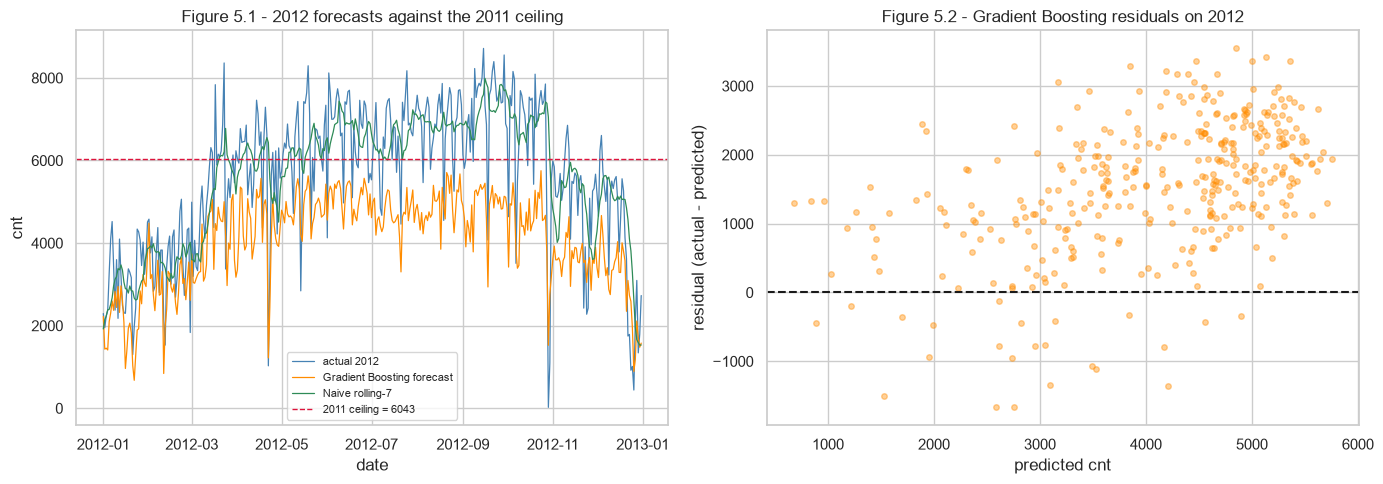

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(test_2012["dteday"], yb_te, lw=0.9, label="actual 2012", color="steelblue")
ax[0].plot(test_2012["dteday"], pred_b["Gradient Boosting"], lw=0.9,
           label="Gradient Boosting forecast", color="darkorange")
ax[0].plot(test_2012["dteday"], naive_preds[best_naive], lw=0.9,
           label=best_naive, color="seagreen")
ax[0].axhline(ceiling_train, color="crimson", ls="--", lw=1,
              label=f"2011 ceiling = {ceiling_train}")
ax[0].set_title("Figure 5.1 - 2012 forecasts against the 2011 ceiling")
ax[0].set_xlabel("date"); ax[0].set_ylabel("cnt"); ax[0].legend(fontsize=8)

resid = yb_te.to_numpy() - pred_b["Gradient Boosting"]
ax[1].scatter(pred_b["Gradient Boosting"], resid, alpha=0.4, s=16, color="darkorange")
ax[1].axhline(0, color="k", ls="--")
ax[1].set_title("Figure 5.2 - Gradient Boosting residuals on 2012")
ax[1].set_xlabel("predicted cnt"); ax[1].set_ylabel("residual (actual - predicted)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_forecast_ceiling.png", dpi=120)
plt.show()

**Reading Table 5.3 and Figures 5.1 and 5.2.** This is the mechanism behind the Protocol B
result, and it is structural rather than a tuning failure. The largest value 2011 ever recorded
is 6,043 rentals in a day. Gradient Boosting's largest forecast for the whole of 2012 is 5,752,
Random Forest's is 5,569 and K-Nearest Neighbors reaches only 5,294 - **every one of them below
the training ceiling, while 2012 actually peaked at 8,714**. A tree predicts by averaging
training targets in a leaf, so it cannot output a number larger than the largest it was trained
on. No amount of tuning changes that; it is what the model class is.

The residual column quantifies the damage: the ensembles under-predict by roughly 1,500 rentals
on an average day across the entire year. Linear Regression is the one model that escapes the
ceiling, forecasting up to 8,247, because a fitted line can be extended past the range it was
estimated on. That single property is why it is the best ML forecaster here despite being the
simplest, and it is still under-predicting by 832 a day. The naive rolling mean, by contrast,
has a mean residual of **-2**: it is essentially unbiased, because it re-anchors on recent
reality every single day instead of relying on a relationship learned a year earlier.

### 5.2 Explaining the model that is actually being recommended

No model passed the Protocol B gates, so there is no approved forecaster to explain. The
explanation below therefore covers the **Protocol A benchmark winner**, and it is presented as
what it is: an account of how the model explains variation across the observed period, not a
description of an approved forecasting system.

SHAP is preferred to scikit-learn's built-in `feature_importances_` because impurity-based
importance is biased towards continuous and high-cardinality variables, which is exactly the
kind of feature this design is full of. The impurity ranking is kept alongside it so the
difference is visible rather than asserted.

Additivity check passed: SHAP contributions reconstruct the model output.

Table 5.4 - Global SHAP importance, Protocol A benchmark winner
Elapsed time and temperature dominate; the calendar dummies contribute far less.


,feature,mean_abs_shap
0,sc__days_since_start,1064.343114
1,sc__temp,310.931970
2,sc__atemp,291.342693
3,sc__temp_sq,283.723715
4,sc__hum,204.517569
5,sc__windspeed,140.185503
6,sc__atemp_hum,96.367889
7,oh__weathersit_2,93.891284
8,pass__workingday,60.029245
9,oh__weekday_6,59.492931


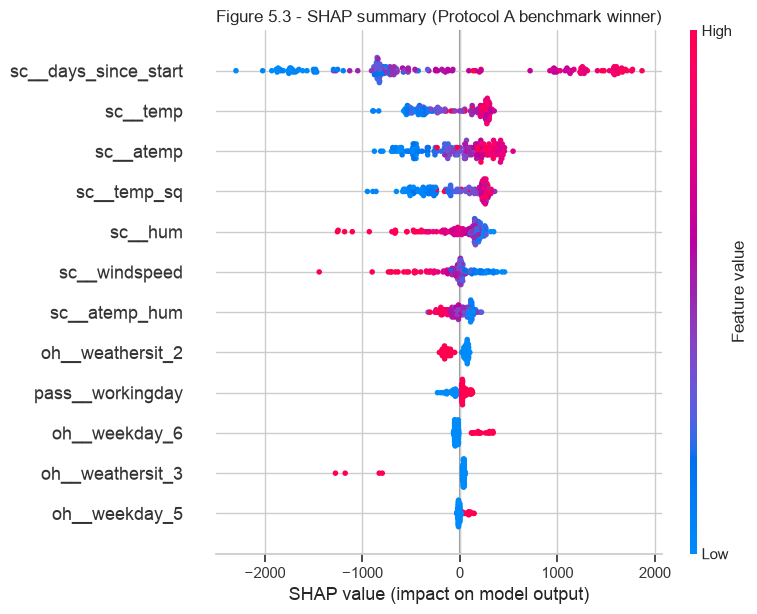

In [28]:
import shap

X_te_a, y_te_a = best_a_test
prep_fitted = best_a_model.named_steps["prep"]
feat_names = list(prep_fitted.get_feature_names_out())
X_te_trans = prep_fitted.transform(X_te_a)
if hasattr(X_te_trans, "toarray"):
    X_te_trans = X_te_trans.toarray()

explainer = shap.TreeExplainer(best_a_model.named_steps["model"])
shap_values = explainer.shap_values(X_te_trans, check_additivity=True)
print("Additivity check passed: SHAP contributions reconstruct the model output.")

global_imp = (pd.DataFrame({"feature": feat_names,
                            "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
              .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
global_imp.to_csv(OUTPUT_DIR / "shap_global_importance_v3.csv", index=False)
print("\nTable 5.4 - Global SHAP importance, Protocol A benchmark winner")
print("Elapsed time and temperature dominate; the calendar dummies contribute far less.")
display(global_imp.head(10))

shap.summary_plot(shap_values, X_te_trans, feature_names=feat_names,
                  max_display=12, show=False)
plt.title("Figure 5.3 - SHAP summary (Protocol A benchmark winner)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

In [29]:
# The biased ranking, kept for contrast rather than for the conclusion
imp = (pd.DataFrame({"feature": feat_names,
                     "impurity_importance": best_a_model.named_steps["model"].feature_importances_})
       .sort_values("impurity_importance", ascending=False).reset_index(drop=True))
imp.to_csv(OUTPUT_DIR / "feature_importance_v3.csv", index=False)

compare_rank = (global_imp.head(8)[["feature"]].assign(shap_rank=range(1, 9))
                .merge(imp.head(8)[["feature"]].assign(impurity_rank=range(1, 9)),
                       on="feature", how="outer"))
print("Table 5.5 - SHAP ranking against impurity ranking, top 8 of each")
print("Where the two disagree, the SHAP ordering is the one this report relies on.")
display(compare_rank)

Table 5.5 - SHAP ranking against impurity ranking, top 8 of each
Where the two disagree, the SHAP ordering is the one this report relies on.


,feature,shap_rank,impurity_rank
0,oh__weathersit_2,8.0,NaN
1,oh__weathersit_3,NaN,6.0
2,sc__atemp,3.0,4.0
3,sc__atemp_hum,7.0,8.0
4,sc__days_since_start,1.0,1.0
5,sc__hum,5.0,5.0
6,sc__temp,2.0,2.0
7,sc__temp_sq,4.0,3.0
8,sc__windspeed,6.0,7.0


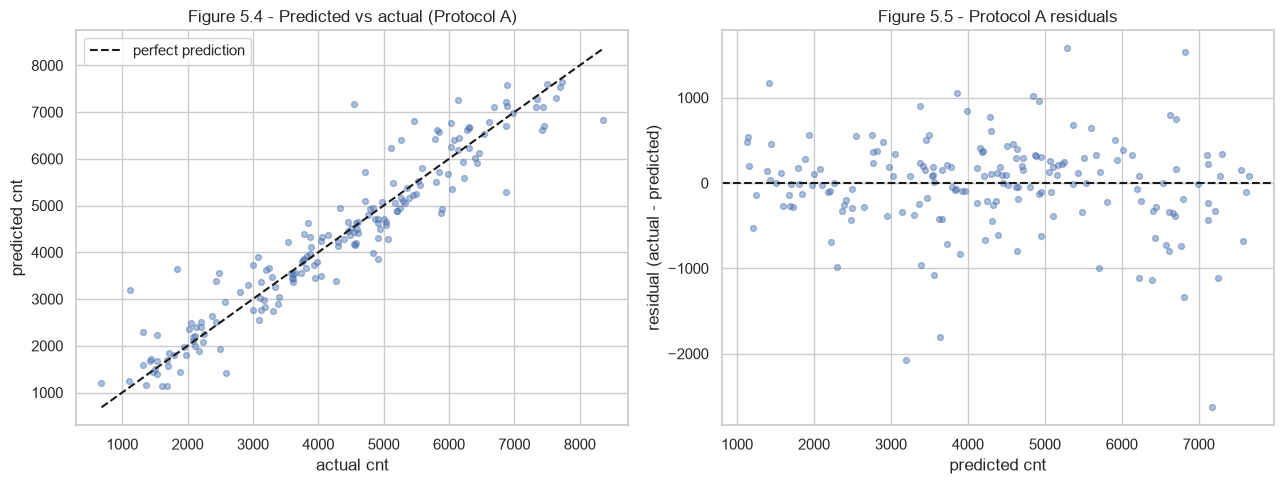

In [30]:
pred_a_best = best_a_model.predict(X_te_a)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_te_a, pred_a_best, alpha=0.45, s=18)
lims = [min(y_te_a.min(), pred_a_best.min()), max(y_te_a.max(), pred_a_best.max())]
ax[0].plot(lims, lims, "k--", label="perfect prediction")
ax[0].set_xlabel("actual cnt"); ax[0].set_ylabel("predicted cnt")
ax[0].set_title("Figure 5.4 - Predicted vs actual (Protocol A)"); ax[0].legend()
ax[1].scatter(pred_a_best, y_te_a - pred_a_best, alpha=0.45, s=18)
ax[1].axhline(0, color="k", ls="--")
ax[1].set_xlabel("predicted cnt"); ax[1].set_ylabel("residual (actual - predicted)")
ax[1].set_title("Figure 5.5 - Protocol A residuals")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_protocol_a_diagnostics.png", dpi=120)
plt.show()

In [31]:
# Table 5.6 - training and inference cost, so the recommendation accounts for more than accuracy
import time

rows = []
for name, m in fit_a.items():
    t0 = time.perf_counter(); m.fit(Xa_tr, ya_tr); fit_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter(); m.predict(Xa_te); pred_ms = (time.perf_counter() - t0) * 1000
    rows.append({"model": name, "fit (ms)": round(fit_ms, 1),
                 "predict (ms)": round(pred_ms, 2),
                 "per-row inference (us)": round(pred_ms / len(Xa_te) * 1000, 1)})
timing = pd.DataFrame(rows).sort_values("fit (ms)")
timing.to_csv(OUTPUT_DIR / "time_complexity_v3.csv", index=False)
print("Table 5.6 - Training and inference cost, Protocol A configuration")
print("All candidates are cheap at this data size; cost is not what separates them.")
display(timing)

Table 5.6 - Training and inference cost, Protocol A configuration
All candidates are cheap at this data size; cost is not what separates them.


,model,fit (ms),predict (ms),per-row inference (us)
2,K-Nearest Neighbors,3.9,2.82,15.6
1,Linear Regression,4.8,2.14,11.8
0,Mean baseline,5.6,2.13,11.8
4,Gradient Boosting,246.2,3.70,20.4
3,Random Forest,545.4,20.43,112.9


In [32]:
# Table 5.7 - approval decided separately per use case, using the permitted-outcome wording
supported_weather = sorted(int(v) for v in model_df["weathersit"].unique())
approval = pd.DataFrame([
    {"use case": "Explaining demand across the observed period (interpolation)",
     "protocol": "A", "model": f"{best_a_name} (core + interactions + trend)",
     "verdict": "Selected as benchmark winner, not operationally approved",
     "reason": f"MAE {a_mae:.1f}, {a_gain*100:.0f}% better than the mean baseline, "
               "but a random split cannot support a claim about tomorrow",
     "supported input domain": f"weathersit {supported_weather}"},
    {"use case": "Day-ahead demand forecasting", "protocol": "B",
     "model": b_win,
     "verdict": "Rejected",
     "reason": f"MAE {b_mae:.1f} against {naive_mae:.1f} for {best_naive}; fails both declared "
               "gates and is beaten by a rule needing no model",
     "supported input domain": f"weathersit {supported_weather}"},
    {"use case": "Day-ahead demand forecasting", "protocol": "B",
     "model": best_naive,
     "verdict": "Retained as the operating procedure",
     "reason": "Lowest MAE and highest R-squared of anything tested, essentially unbiased "
               "(mean residual -2), and needs no training or maintenance",
     "supported input domain": "not applicable: uses only recorded demand"},
])
approval.to_csv(OUTPUT_DIR / "approval_table_v3.csv", index=False)
print("Table 5.7 - Approval decisions, one per use case")
print("Only Protocol B rows carry an operational verdict.")
display(approval)

Table 5.7 - Approval decisions, one per use case
Only Protocol B rows carry an operational verdict.


,use case,protocol,model,verdict,reason,supported input domain
0,Explaining demand across the observed period (...,A,Gradient Boosting (core + interactions + trend),"Selected as benchmark winner, not operationall...","MAE 383.8, 74% better than the mean baseline, ...","weathersit [1, 2, 3]"
1,Day-ahead demand forecasting,B,Linear Regression,Rejected,MAE 1047.4 against 847.8 for Naive rolling-7; ...,"weathersit [1, 2, 3]"
2,Day-ahead demand forecasting,B,Naive rolling-7,Retained as the operating procedure,Lowest MAE and highest R-squared of anything t...,not applicable: uses only recorded demand


### 5.3 What the evaluation establishes

Protocol A cleared its declared bar comfortably. Gradient Boosting explains daily demand across
2011 and 2012 to within about 384 rentals on the configuration the ablation selected, roughly
8% of mean daily demand, a 74% improvement on the mean baseline. As a benchmark answer to "which
model performs best on this dataset", that is the answer, and Table 5.7 records it as exactly
that and nothing more.

Protocol B failed both of its gates, and the decision rule that fired is the third row of the
table declared in Section 1.5: **the naive baseline wins and machine learning is rejected for
day-ahead forecasting.** The wording matters. This is not "the improvement was not material".
The best model was 23.5% worse than a trailing seven-day average, and the paired test over 366
days puts the probability of that gap arising from sampling noise at effectively nil, with the
caveat that autocorrelated daily errors make the p-value indicative rather than exact.

Three things make this a finding rather than a failure.

First, it is **mechanistic, not mysterious**. Table 5.3 shows the ensembles cannot produce a
number above their training ceiling while half of 2012 sits above it, so their failure was
determined before any hyperparameter was chosen.

Second, it is **specific about what would change the answer**. The ablation shows the
forecasting signal these models can use comes almost entirely from recent demand, and the naive
rule already uses recent demand directly and without error. A model earns its place here only
by adding something the rolling mean lacks, and one year of history does not supply it.

Third, it **survived a fair fight**. The models were given autoregressive features, cyclical
encoding, tuning inside the training year, and the same dates as the baseline. The naive rule
won anyway.

## 6. Deployment and Lessons Learned

### 6.1 What I would actually put into production

The honest recommendation from this study is a two-part system, and only one part is a model.

**For day-ahead demand planning, deploy the trailing seven-day mean.** It produced the lowest
error of anything tested, it is essentially unbiased across a year of 64% growth, it needs no
training, no retraining and no feature pipeline, and any operator can reproduce it from a
dashboard. Recommending a model I have just measured to be 23.5% worse would be recommending
the more impressive-sounding option rather than the better one.

**For demand explanation and scenario analysis, use the Protocol A Gradient Boosting model.**
It answers a different and genuinely useful question: how much of the variation in daily demand
is attributable to temperature, season, day type and elapsed time. That supports capacity
planning conversations and marketing analysis. It does not support a claim about tomorrow, and
Table 5.7 says so on its face.

### 6.2 Deployment requirements, regardless of which component is running

- **Out-of-domain weather detection.** `weathersit` category 4 never appears in the training
  data. With `handle_unknown="ignore"` an unseen category encodes identically to the reference
  category, so a severe-weather day would be silently scored as if it were clear. The supported
  domain must be recorded alongside the model and validated at the input boundary, with
  out-of-domain days escalated to human review rather than predicted.
- **Error monitoring against the naive rule.** Whatever runs in production should be scored
  daily against the rolling seven-day mean. The day the model stops beating it is the day it
  should be retired, and this study shows that day can be the first one.
- **Multi-year history before any trend claim.** Two years is one repetition. The trend feature
  that helped under Protocol A and hurt under Protocol B is the concrete demonstration: with a
  single growth curve there is no way to tell a durable trend from a one-off level shift.
- **The forecast-versus-observed weather gap.** This dataset contains observed weather. A
  production system would receive forecast weather, which carries its own error that this study
  cannot measure and that would make every Protocol B number reported here optimistic.

### 6.3 Lessons learned

**The split defines the claim.** The same data, the same five models and the same metric
produce MAE 384 under one split and 1,628 under another. Neither number is wrong; they answer
different questions. The mistake would have been to report the flattering one and describe it
in forecasting language, which is what a random split over a time series quietly invites.

**A feature is not good or bad on its own.** Elapsed time gave the best result in this notebook
and one of the worst, from the same column, decided entirely by whether the model was asked to
interpolate or to extrapolate. Feature selection without a protocol attached is not a
meaningful activity.

**Model class beats tuning when the class is wrong.** Linear Regression outperformed two tuned
ensembles under Protocol B, not by being more accurate but by being able to extrapolate at all.
No grid search over trees could have closed that gap.

**Baselines have to be strong enough to lose to.** Had I benchmarked against the constant mean,
as the first version of this project did, every model would have looked like a success. The
naive rules cost almost nothing to compute and they changed the entire conclusion.

**Declaring criteria in advance is what makes a negative result reportable.** The gates in
Section 1 were fixed before any v3 model ran, so this report can state a rejection plainly
instead of retrofitting a threshold the winner happens to clear. That said, the criteria were
set after the earlier version had already surfaced the naive baselines, which is weaker than a
blind pre-registration, and Section 1.6 says so rather than claiming more independence than the
process had.

### 6.4 Future work

Aggregating the hourly file to build intra-day features, adding public-holiday and event
calendars, testing models built for extrapolation such as gradient boosting on differenced
targets or an explicit trend-plus-seasonality decomposition, and above all obtaining more than
two years of history so that a seasonal pattern can be separated from a growth curve.

---

## Appendix A - Glossary

| Term | Meaning in this report |
|---|---|
| **MAE** | Mean absolute error, average size of the miss in rentals per day. The brief's primary metric and the one used for every gate. |
| **MSE / RMSE** | Mean squared error and its root. Squaring punishes large misses, so RMSE rises above MAE when errors are uneven. |
| **R-squared** | Share of variance explained. Negative means the model predicts worse than the mean of the evaluated period. |
| **Interpolation** | Predicting inside the range and period the model was trained on. |
| **Extrapolation** | Predicting outside it, which tree ensembles structurally cannot do. |
| **Day-ahead horizon** | Running the model at the close of day D to predict day D+1, with all counts up to D known. |
| **Autoregressive feature** | An input built from the target's own past, such as yesterday's count. |
| **Causal construction** | Building such a feature so its window ends strictly before the target day. |
| **Naive baseline** | A rule needing no model: yesterday's count, last week's count, or a trailing mean. |
| **TimeSeriesSplit** | Cross-validation with expanding windows that never lets a fold train on data later than it validates. |
| **Cyclical encoding** | Mapping a calendar value to a sine and cosine pair, defined for values never seen in training. |
| **SHAP** | Additive attribution of a prediction to its features, preferred here to impurity importance, which is biased towards continuous variables. |
| **Wilcoxon signed-rank** | Non-parametric paired test used here on daily absolute errors. |

## Appendix B - Proposed operational deployment

```mermaid
flowchart LR
    A["Nightly job, 22:00<br/>day D closes"] --> B["Read demand history<br/>through day D"]
    B --> C["Rolling 7-day mean<br/>= day D+1 forecast"]
    B --> D["Protocol A model<br/>explanation and scenarios"]
    C --> E{"weathersit forecast<br/>in supported domain?"}
    E -->|"1, 2 or 3"| F["Publish forecast<br/>to staffing and fleet"]
    E -->|"4 or unknown"| G["Escalate to<br/>human review"]
    F --> H["Next morning:<br/>score yesterday's forecast"]
    H --> I{"Still beating<br/>the naive rule?"}
    I -->|no| J["Retire the component"]
```

The forecasting path deliberately contains no learned model. The learned model sits on the
explanation branch, where a random split can support its claims.

In [33]:
# Reproducibility - the exact environment these numbers came from
import sys, sklearn, scipy, matplotlib
print("Python      :", sys.version.split()[0])
for mod in (np, pd, sklearn, scipy, matplotlib, sns, shap):
    print(f"{mod.__name__:12s}:", mod.__version__)
print("RANDOM_STATE:", RANDOM_STATE)
print("Rows modelled:", len(model_df), "| Protocol A test:", len(Xa_te),
      "| Protocol B confirmation:", len(test_2012))

Python      : 3.14.3
numpy       : 2.4.6
pandas      : 3.0.3
sklearn     : 1.9.0
scipy       : 1.18.0
matplotlib  : 3.11.0
seaborn     : 0.13.2
shap        : 0.52.0
RANDOM_STATE: 42
Rows modelled: 724 | Protocol A test: 181 | Protocol B confirmation: 366


---

## Academic Integrity Declaration

I declare that this submission is my own work. All sources of information, ideas and code have
been acknowledged. The dataset is publicly available from the UCI Machine Learning Repository.
The analysis, modelling decisions, interpretation and written commentary are my own.

## Statement of Acknowledgement

Analysis was performed in Python with pandas, NumPy, scikit-learn, SciPy, SHAP, Matplotlib and
Seaborn. I used an AI assistant (Anthropic Claude) as a study and review aid: to challenge my
experimental design, to check that my measured claims matched my output tables, and to review
drafting for clarity. All modelling decisions, the two-protocol design, the declared gates and
decision rules, the interpretation of every result and the final recommendation are my own, and
every number reported here is produced by the code in this notebook.

## References

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5-32.
https://doi.org/10.1023/A:1010933404324

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R.
(2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Fanaee-T, H., & Gama, J. (2014). Event labeling combining ensemble detectors and background
knowledge. *Progress in Artificial Intelligence, 2*, 113-127.
https://doi.org/10.1007/s13748-013-0040-3

Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *Annals of
Statistics, 29*(5), 1189-1232. https://doi.org/10.1214/aos/1013203451

Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3rd ed.).
OTexts. https://otexts.com/fpp3/

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions.
*Advances in Neural Information Processing Systems, 30*, 4765-4774.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... &
Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning
Research, 12*, 2825-2830.

Shaukat, K., Luo, S., & Varadharajan, V. (2024). A novel machine learning approach for
detecting first-time-appeared malware. *Engineering Applications of Artificial Intelligence,
131*, 107801. https://doi.org/10.1016/j.engappai.2023.107801

Strobl, C., Boulesteix, A.-L., Zeileis, A., & Augustin, T. (2007). Bias in random forest
variable importance measures. *BMC Bioinformatics, 8*, 25.
https://doi.org/10.1186/1471-2105-8-25

University of California, Irvine. (n.d.). *Bike Sharing Dataset* [Data set]. UCI Machine
Learning Repository. https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

Wilcoxon, F. (1945). Individual comparisons by ranking methods. *Biometrics Bulletin, 1*(6),
80-83. https://doi.org/10.2307/3001968